In [1]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison
import dotenv
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
# import environment variables
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")

5_model_alpha=0.0500,model_encoder_size=512,model_latent_size=3,model_vf_num_layers=6


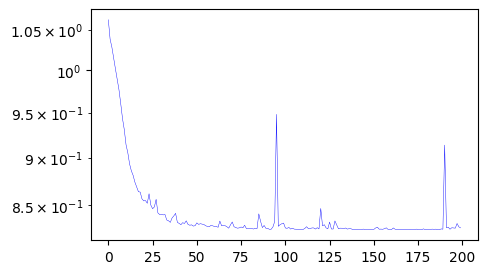

13_model_alpha=0.0500,model_encoder_size=512,model_latent_size=10,model_vf_num_layers=6


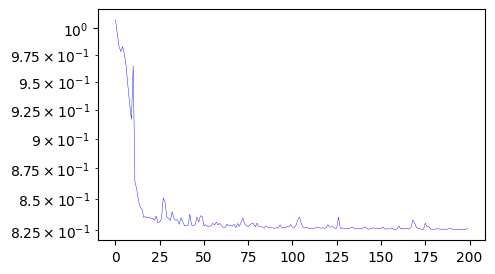

1_model_alpha=0.0500,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=6


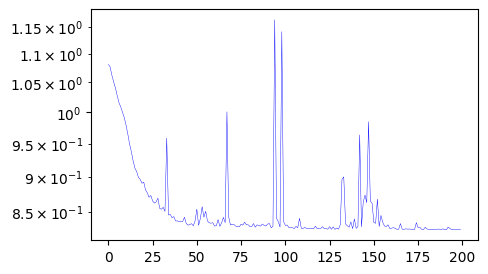

0_model_alpha=0.1000,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=6


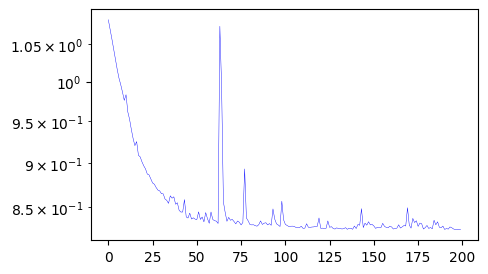

2_model_alpha=0.1000,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=6


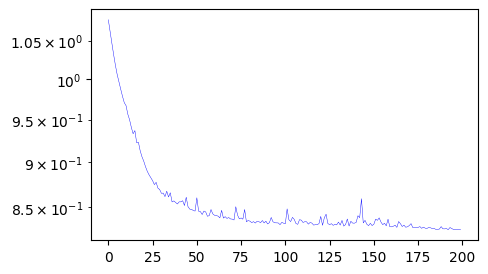

16_model_alpha=0.1000,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=3


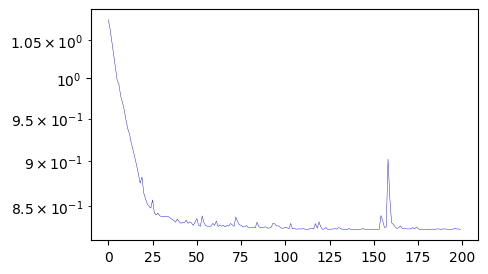

11_model_alpha=0.0500,model_encoder_size=128,model_latent_size=5,model_vf_num_layers=6


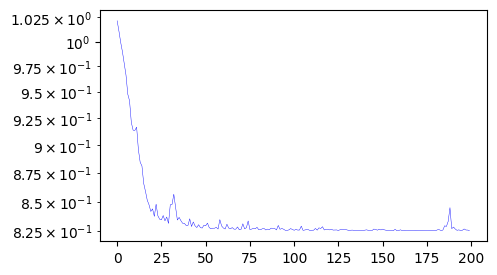

15_model_alpha=0.0500,model_encoder_size=128,model_latent_size=10,model_vf_num_layers=6


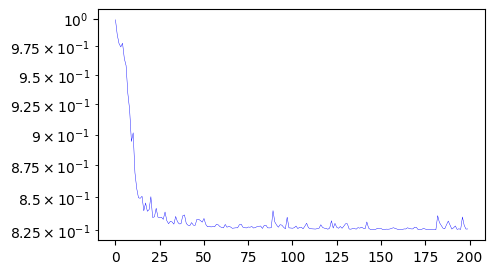

9_model_alpha=0.0500,model_encoder_size=512,model_latent_size=5,model_vf_num_layers=6


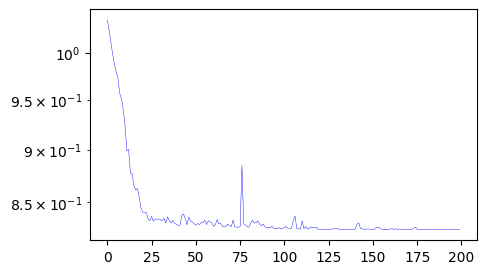

10_model_alpha=0.1000,model_encoder_size=128,model_latent_size=5,model_vf_num_layers=6


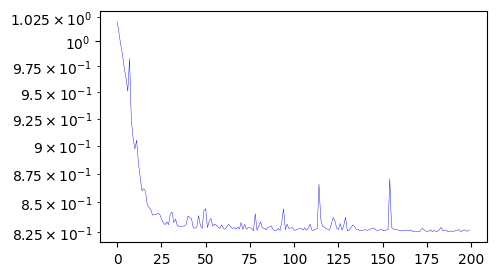

12_model_alpha=0.1000,model_encoder_size=512,model_latent_size=10,model_vf_num_layers=6


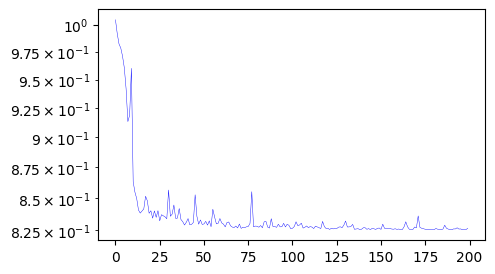

8_model_alpha=0.1000,model_encoder_size=512,model_latent_size=5,model_vf_num_layers=6


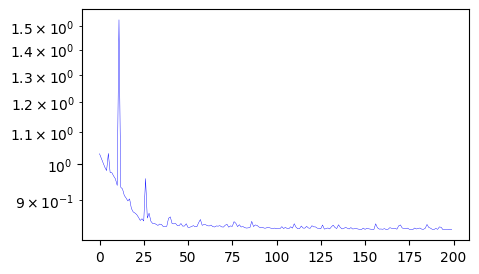

17_model_alpha=0.0500,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=3


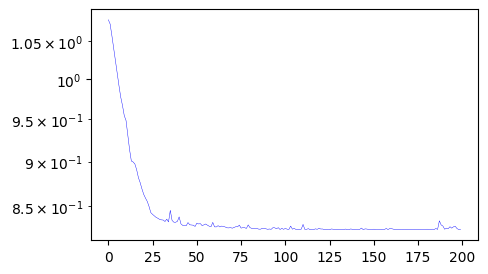

3_model_alpha=0.0500,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=6


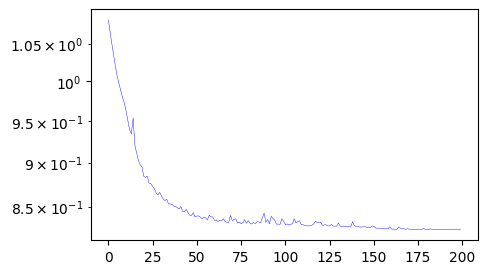

18_model_alpha=0.1000,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=3


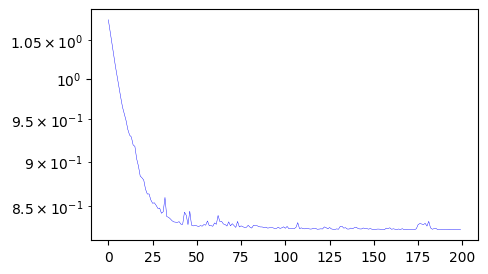

6_model_alpha=0.1000,model_encoder_size=128,model_latent_size=3,model_vf_num_layers=6


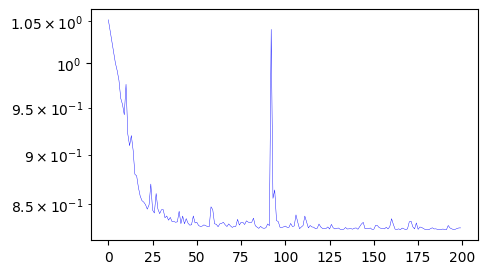

7_model_alpha=0.0500,model_encoder_size=128,model_latent_size=3,model_vf_num_layers=6


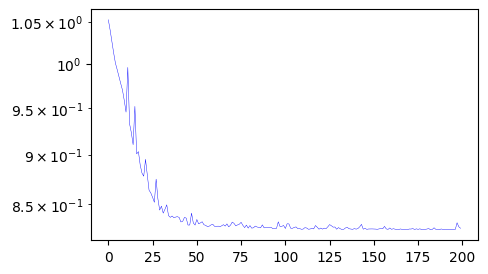

14_model_alpha=0.1000,model_encoder_size=128,model_latent_size=10,model_vf_num_layers=6


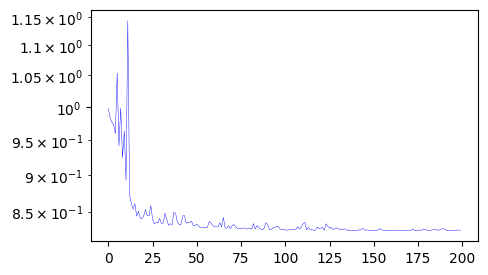

4_model_alpha=0.1000,model_encoder_size=512,model_latent_size=3,model_vf_num_layers=6


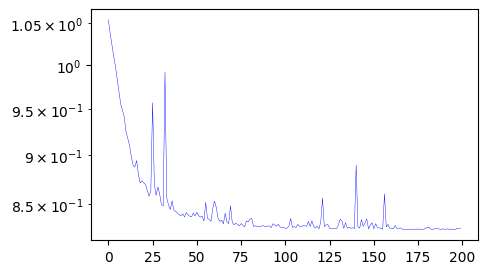

19_model_alpha=0.0500,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=3


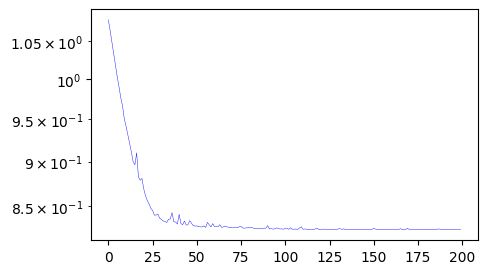

18_model_alpha=0.1000,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=3: 0.8251590728759766
17_model_alpha=0.0500,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=3: 0.8251919746398926
19_model_alpha=0.0500,model_encoder_size=128,model_latent_size=2,model_vf_num_layers=3: 0.8251954913139343
11_model_alpha=0.0500,model_encoder_size=128,model_latent_size=5,model_vf_num_layers=6: 0.8252255320549011
16_model_alpha=0.1000,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=3: 0.8253133893013
9_model_alpha=0.0500,model_encoder_size=512,model_latent_size=5,model_vf_num_layers=6: 0.8254028558731079
0_model_alpha=0.1000,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=6: 0.8257173299789429
14_model_alpha=0.1000,model_encoder_size=128,model_latent_size=10,model_vf_num_layers=6: 0.8257347941398621
1_model_alpha=0.0500,model_encoder_size=512,model_latent_size=2,model_vf_num_layers=6: 0.8257617950439453
15_model_alpha=0.0500,model_encoder_size=1

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json

RUN_DIR = "/scratch/gpfs/ad2002/content/runs/data-trained/20250409_NODE_NODE_PC_1_lin"
TRAINED_MODELS_DIR = ""

TOTAL_ITERS = 200
SHOW_LOSS_CURVES = False

dirs = os.listdir(RUN_DIR)
# retrieve the last training for that model and task
latest_dir = dirs[len(dirs)-2]
# get all hyperparam combs for the latest train run
tunes = os.listdir(RUN_DIR + "/" + latest_dir)
losses = {}

for tune in tunes:
    
    prog_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/progress.csv'
    params_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/params.json'
    if os.path.exists(prog_path):
        df = pd.read_csv(prog_path)
        loss = df.iloc[:, 0]
#         print("tune params: ", tune)
#         print("final loss: ", loss[len(loss)-1])
#         print("completed? ", len(loss) == TOTAL_ITERS)

        if len(loss) == TOTAL_ITERS:
            print(tune)
            losses[tune] = loss[len(loss)-1]
              
            fig, ax = plt.subplots(figsize=(5, 3), dpi=100)
            ax.plot(loss, linestyle="-", color="b", label="val loss", linewidth=0.3)
            ax.set_yscale('log')
            plt.show()

sorted_items = sorted(losses.items(), key=lambda item: item[1])

# Print the sorted key-value pairs
for key, value in sorted_items:
    print(f"{key}: {value}")



# Analyze DD, each for NODE PC: PC_NODE_1_lin & PC_NODE_1_nonlin

In [3]:
# DD linear trained on linear TT sim data

DD_SWEEP_DIR = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250409_NODE_NODE_PC_1_lin"

# add all models trained in that dir
for dirpath, dirnames, filenames in os.walk(DD_SWEEP_DIR):
    for dirname in dirnames:
        analysisDD = Analysis_DD.create(run_name = dirname, 
                                        filepath = os.path.join(DD_SWEEP_DIR, dirname) + "/",
                                        model_type = "SAE")
        print(dirname)
        analysisDD.plot_rates(phase="val", neurons=[0,1,2,4,5], n_trials=2)

# really good letting the sweep continue

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


DT_593b2249


KeyboardInterrupt: 

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


DT_75a8551b


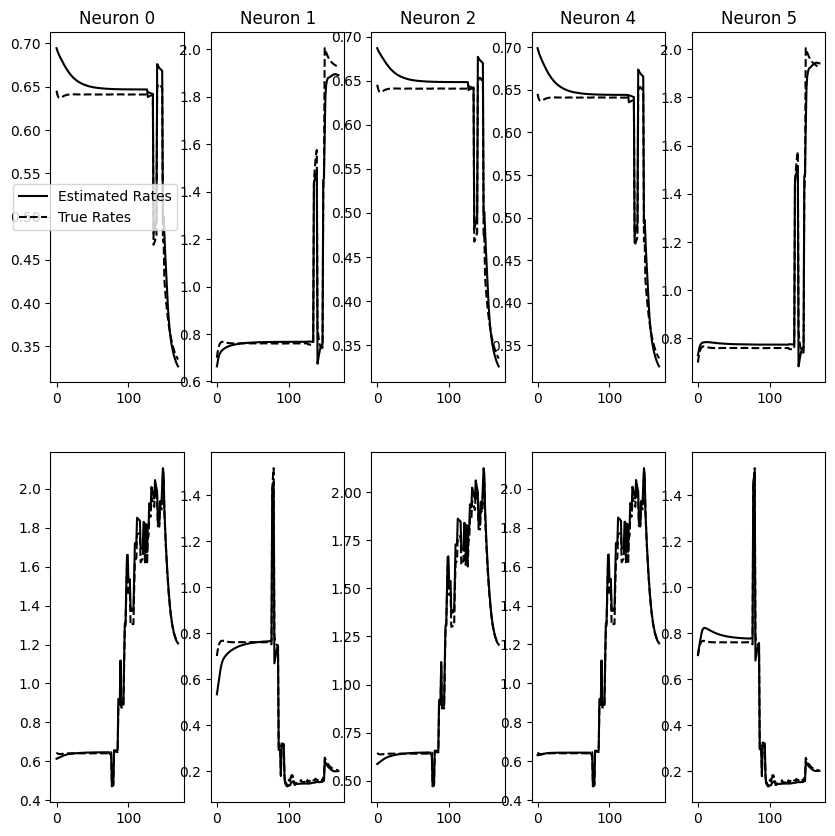

DT_eb297bde


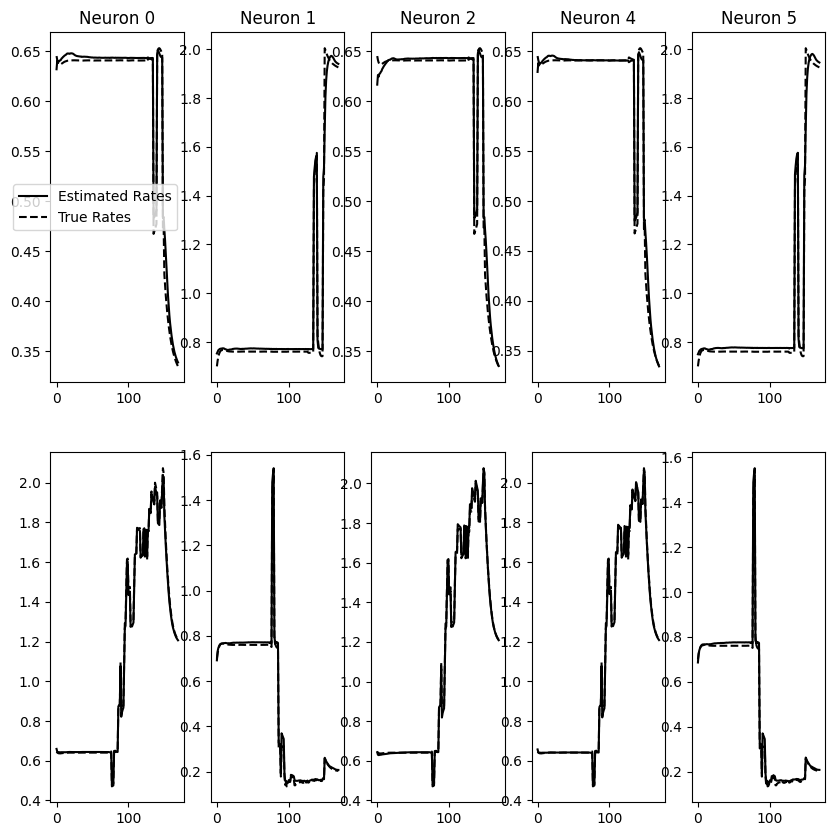

DT_508af7b0


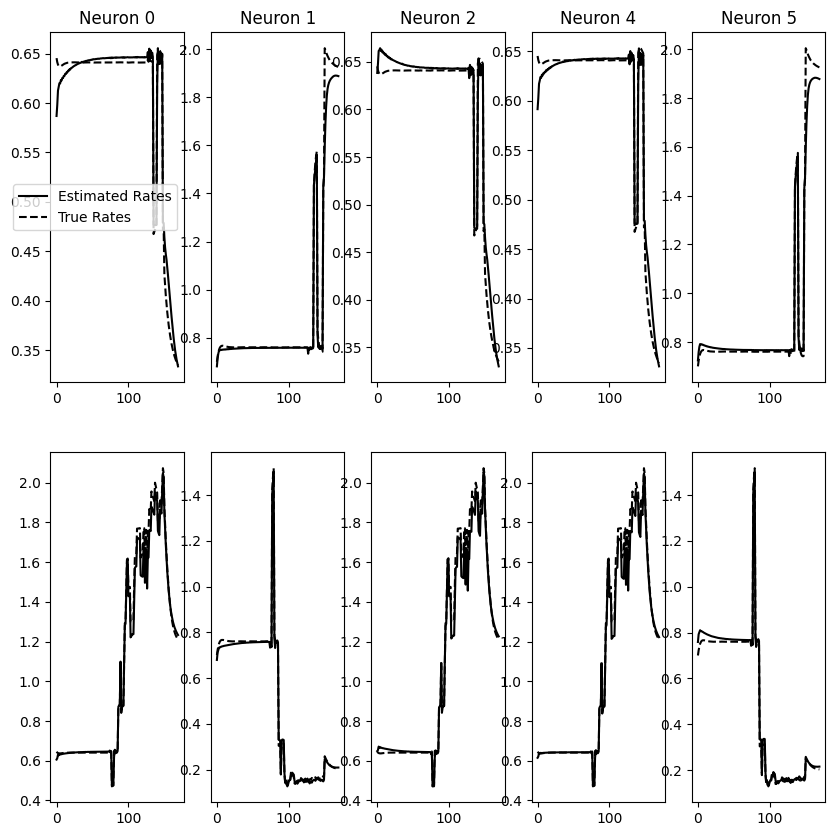

DT_aedacc40


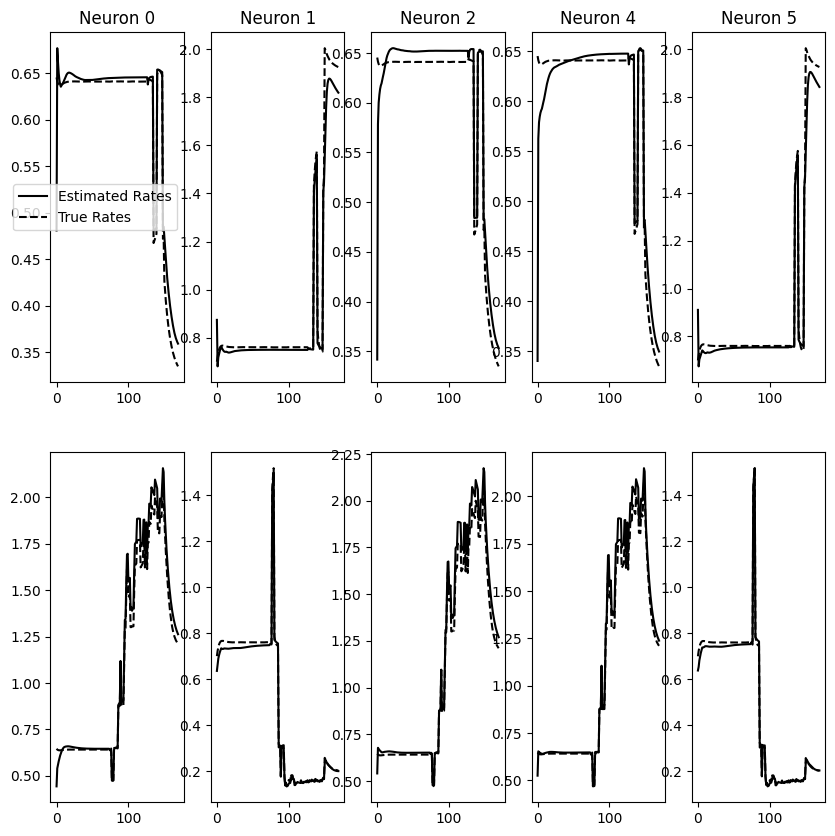

DT_e555b211


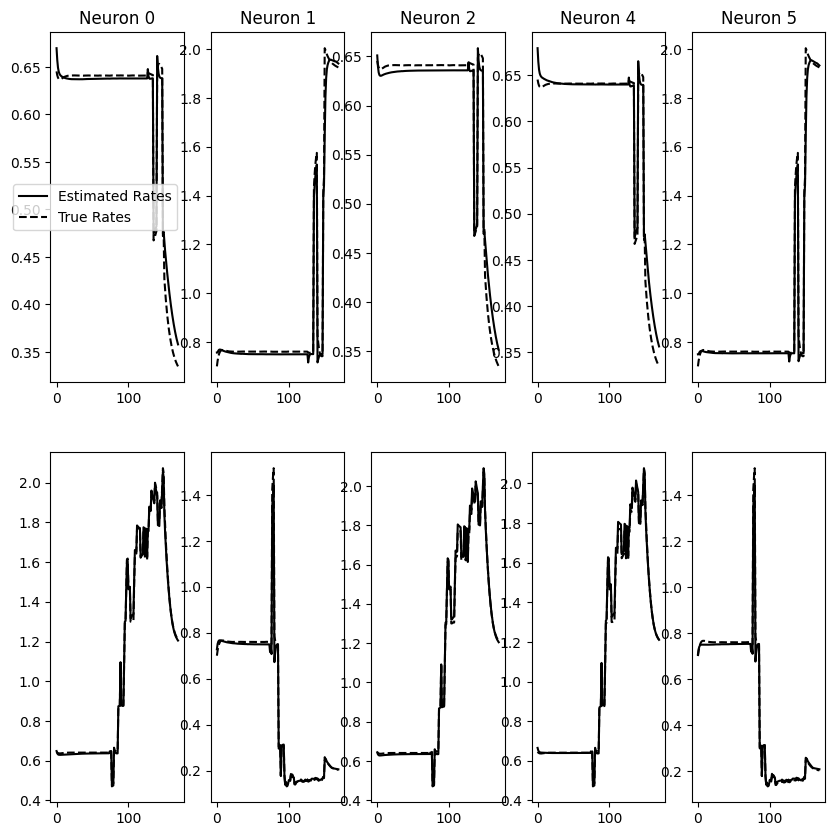

DT_d2da4024


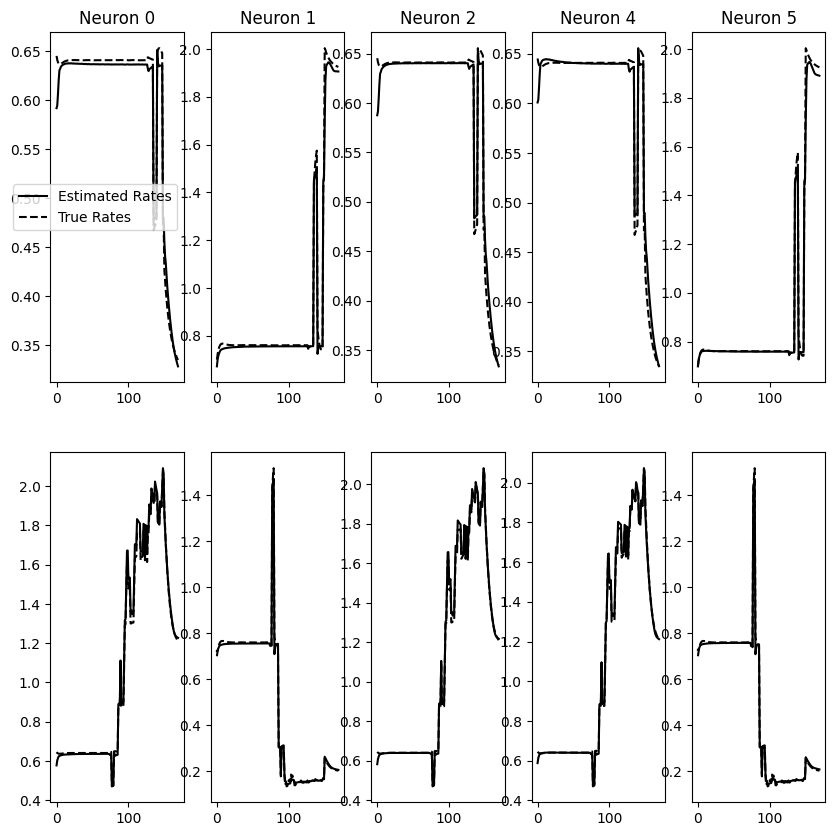

DT_17da52ea


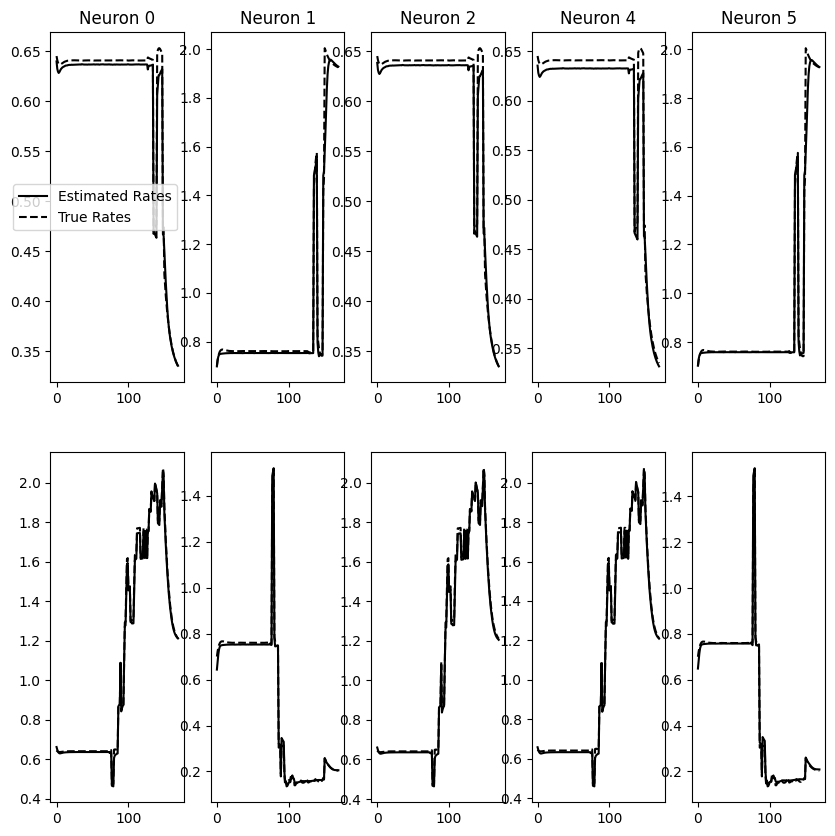

DT_16016b80


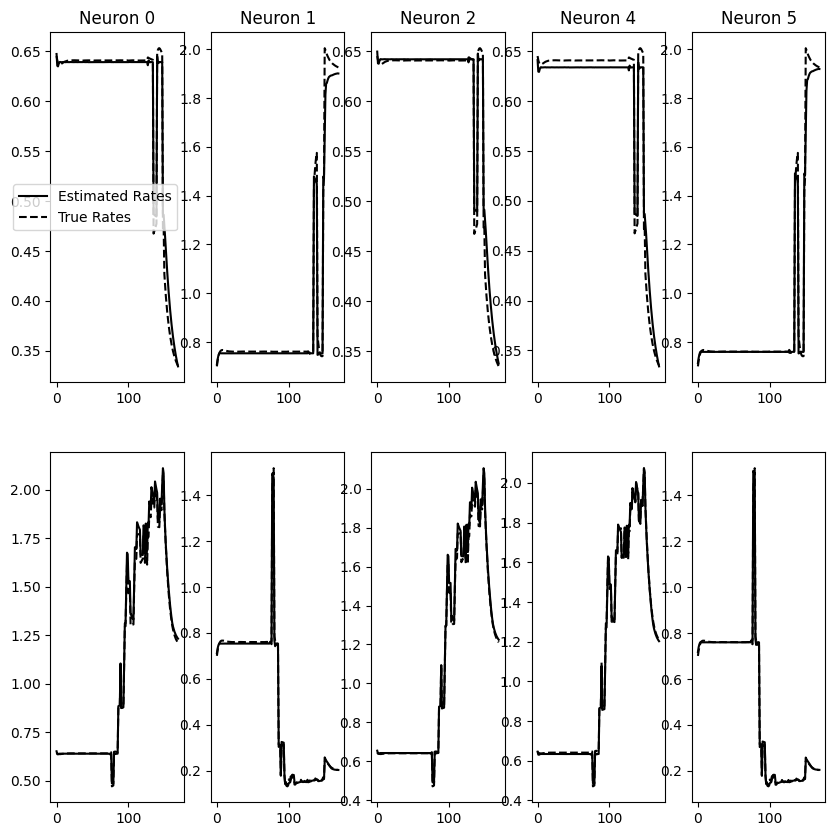

DT_2f600c9a


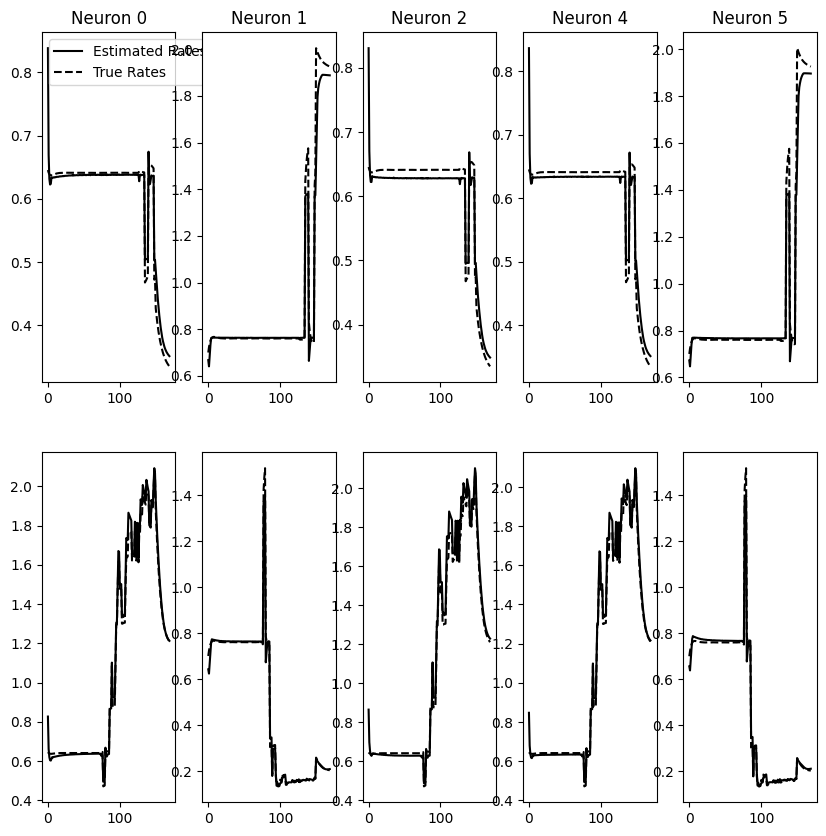

DT_f14cd678


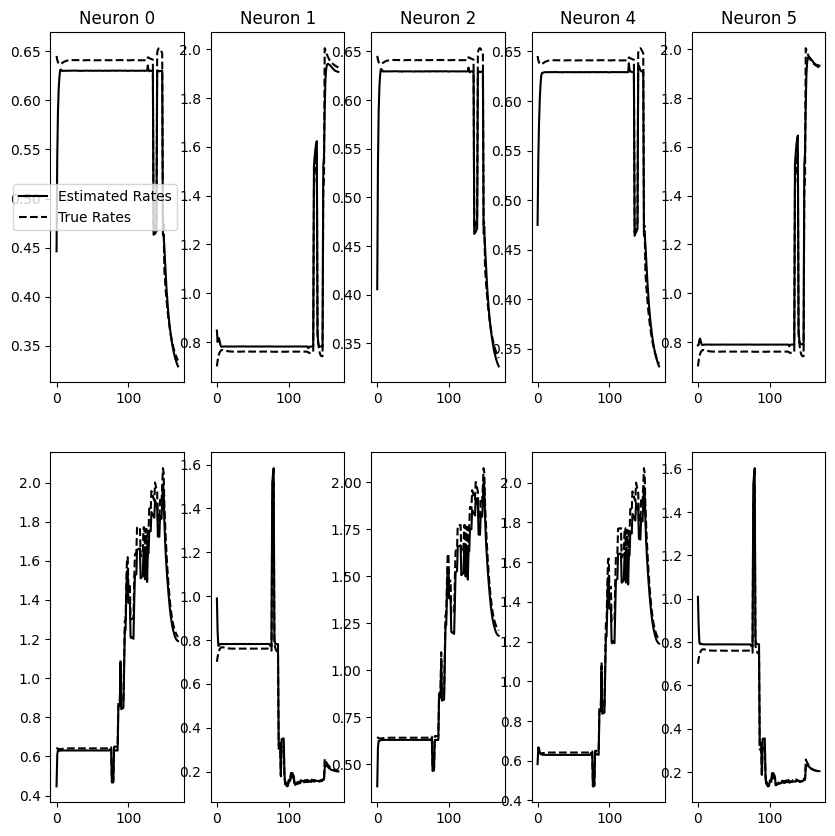

DT_11f6457b


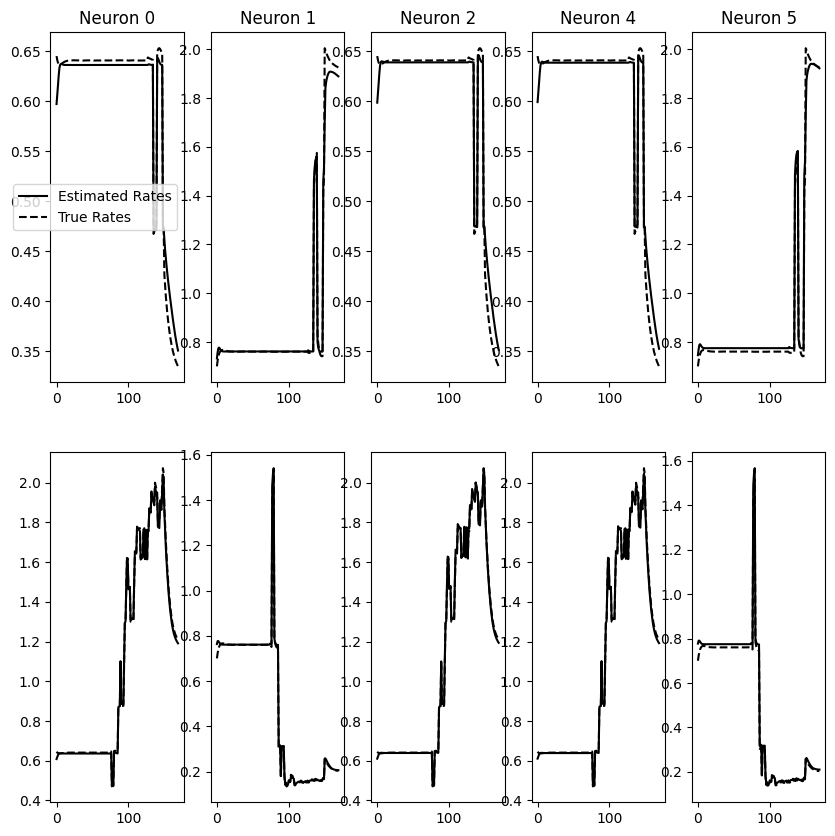

DT_be14890c


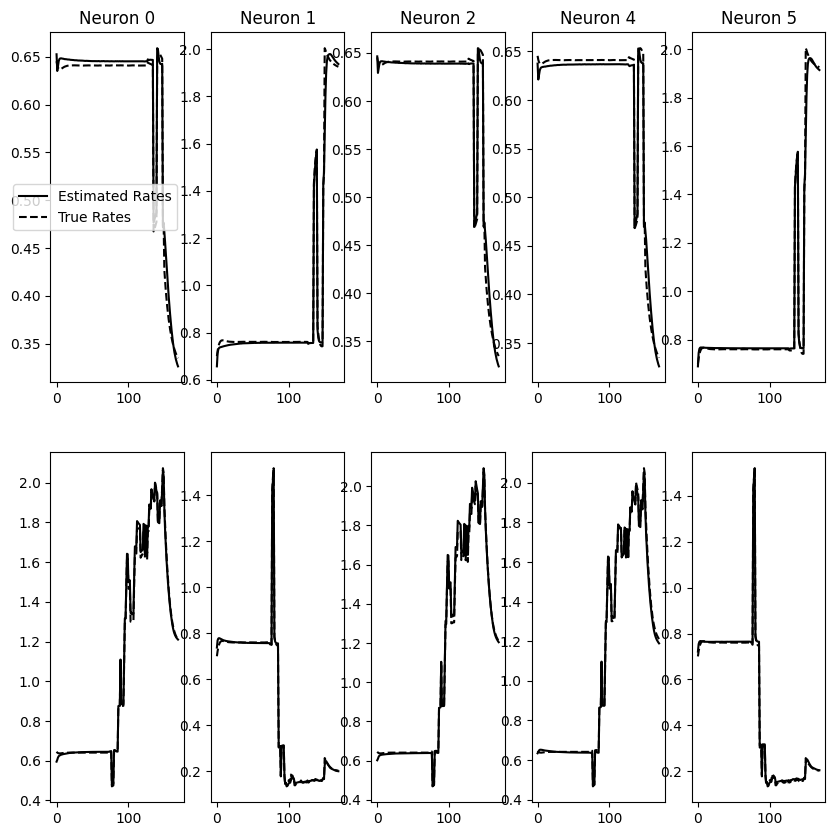

DT_70561174


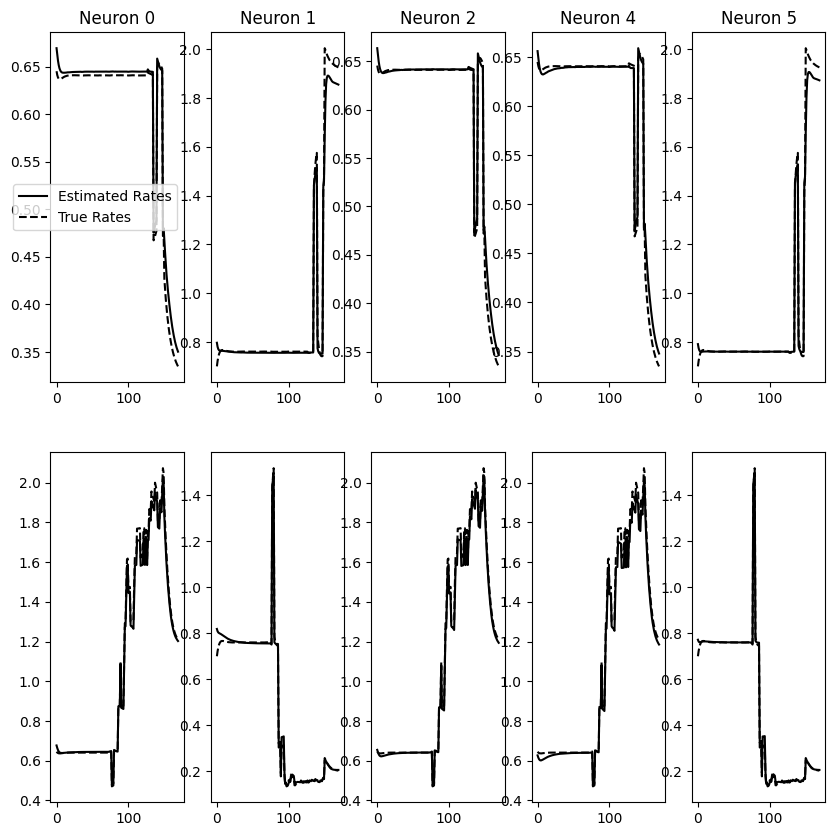

DT_b511ba3a


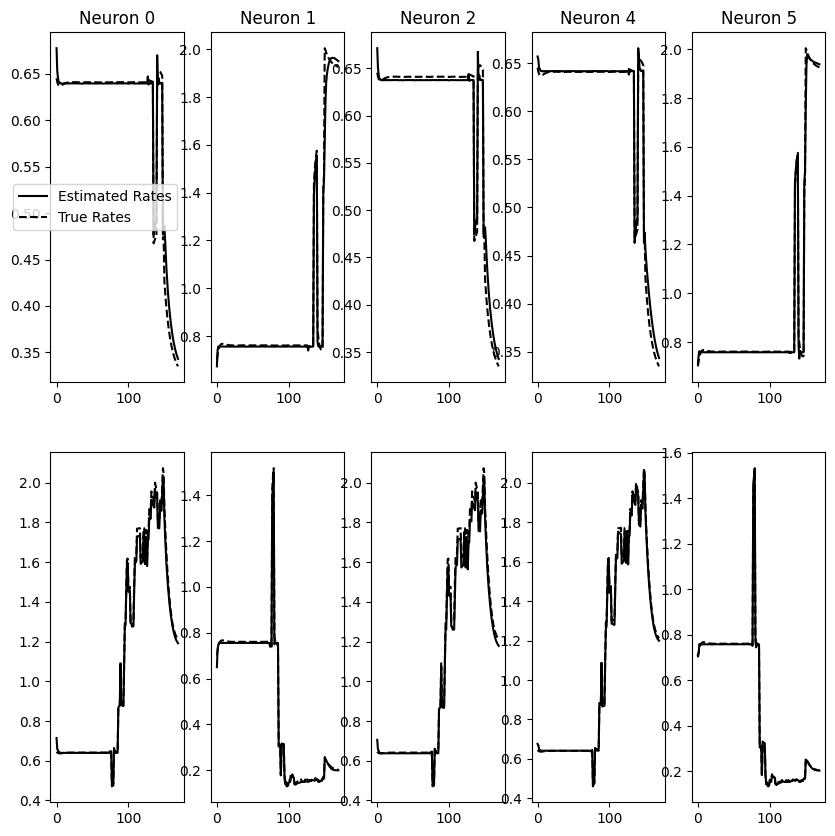

DT_31b57b45


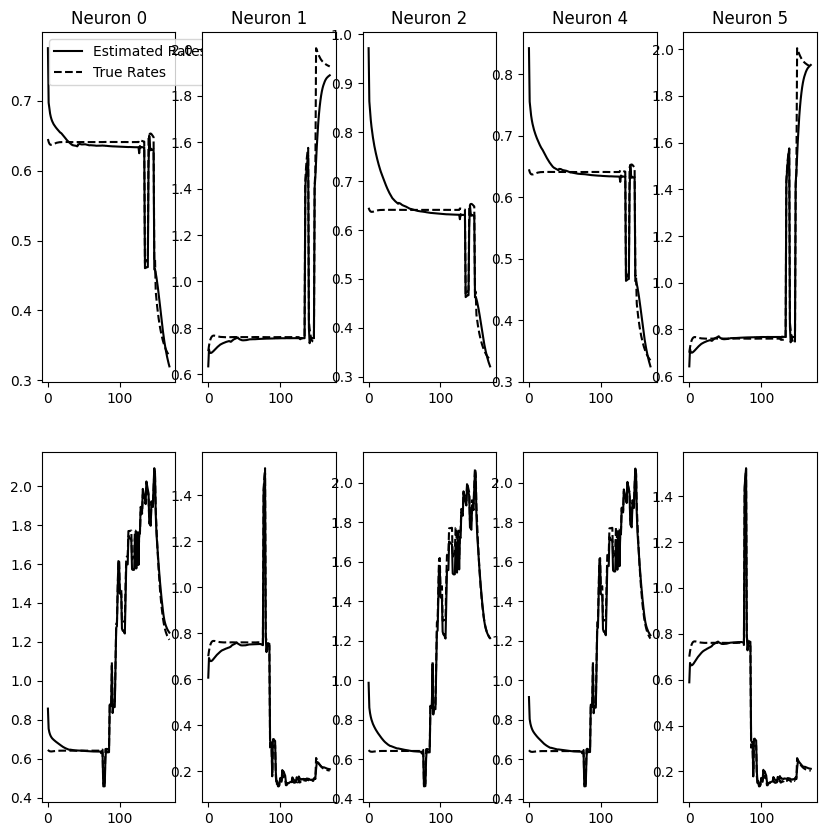

DT_3c24f3f8


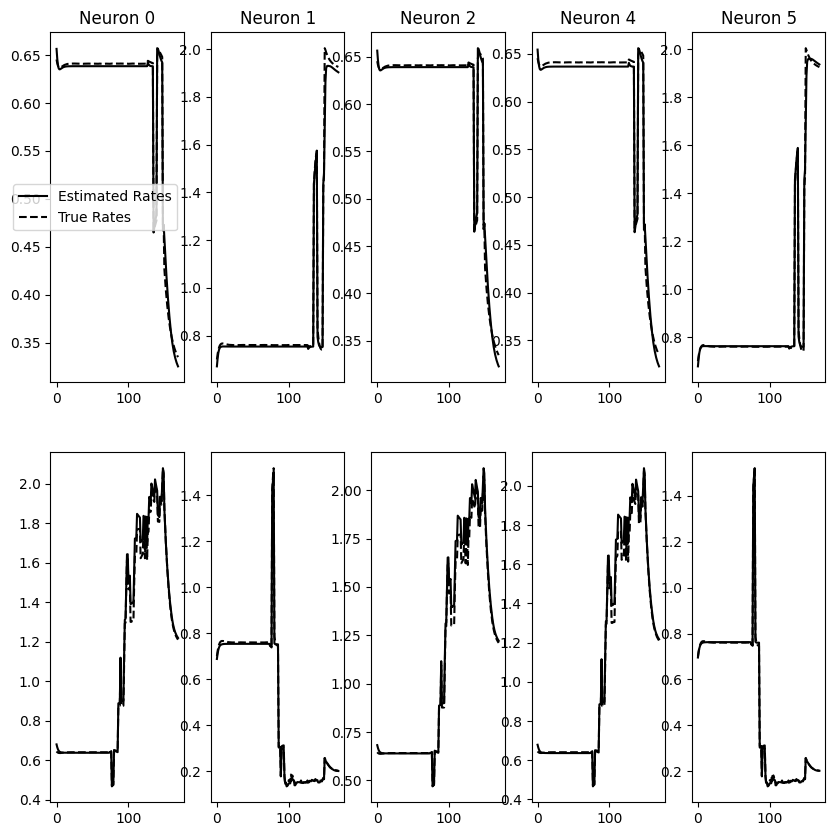

In [13]:
# DD NOT linear trained on NOT linear TT sim data - only DSA is valid to compare their dynamics

DD_SWEEP_DIR = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_NODE_NODE_PC_1_nonlin"

# add all models trained in that dir
for dirpath, dirnames, filenames in os.walk(DD_SWEEP_DIR):
    for dirname in dirnames:
        analysisDD = Analysis_DD.create(run_name = dirname, 
                                        filepath = os.path.join(DD_SWEEP_DIR, dirname) + "/",
                                        model_type = "SAE")
        print(dirname)
        analysisDD.plot_rates(phase="val", neurons=[0,1,2,4,5], n_trials=2)

# Compare linear metrics 

*Sim data on which DD models are trained comes from NODE, w/leak, linear, size=2*

In [2]:
TT_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

tt_node = Analysis_TT(run_name = "20250407_PC_NODE_grid_final", filepath= TT_NODE + "/") 

# load the reference TT model from NODE, size=2
comparator = Comparison(comparison_tag = "node_pc")
analysis = Analysis_TT(run_name = "20250407_PC_NODE_grid_final", filepath= TT_NODE + "/") 
comparator.load_analysis(analysis, group = "NODE-PC-2", reference_analysis=True)

In [3]:
# load DD

LIN280 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250409_NODE_NODE_PC_1_lin"
LIN280_2 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_lin_280:20_1"
LIN250 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_lin_250:50_1"
LIN200 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_lin_200:100_1"

NONLIN280 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_NODE_NODE_PC_1_nonlin"
NONLIN280_2 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_nonlin_280:20_1"
NONLIN250 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_nonlin_250:50_1"
NONLIN200 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250410_nonlin_200:100_1"

for DD_SWEEP_DIR in[LIN280 , LIN280_2, LIN250 , LIN200 ]:
    # add all models trained in that dir
    for dirpath, dirnames, filenames in os.walk(DD_SWEEP_DIR):
        for dirname in dirnames:
            analysisDD = Analysis_DD.create(run_name = dirname, 
                                            filepath = os.path.join(DD_SWEEP_DIR, dirname) + "/",
                                            model_type = "SAE")
            comparator.load_analysis(analysisDD, group = "linear")

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [18]:
# metrics only apply to models w/ linear embeddings in neural space

metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_dict = comparator.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)

metrics_dict_keep = metrics_dict.copy()


Working on 1 of 53: 20250407_PC_NODE_grid_final

Working on 2 of 53: DT_707c0cca
State R2: 0.9792163968086243
Rate R2: 0.9986989498138428
CO-BPS: 0.2742229998111725
Cycle Consistency R2: 1.0

Working on 3 of 53: DT_5c38b333
State R2: 0.9773301482200623
Rate R2: 0.9982818365097046
CO-BPS: 0.2741307318210602
Cycle Consistency R2: 0.9991158843040466

Working on 4 of 53: DT_7173f9ea
State R2: 0.9797700047492981
Rate R2: 0.9992685914039612
CO-BPS: 0.27426567673683167
Cycle Consistency R2: 0.9999020099639893

Working on 5 of 53: DT_d7dffc1f
State R2: 0.8861558437347412
Rate R2: 0.9964790344238281
CO-BPS: 0.27379047870635986
Cycle Consistency R2: 0.9445388913154602

Working on 6 of 53: DT_df77dd6f
State R2: 0.9822348952293396
Rate R2: 0.9993225932121277
CO-BPS: 0.2742953598499298
Cycle Consistency R2: 0.9999744892120361

Working on 7 of 53: DT_558e9526
State R2: 0.7315465807914734
Rate R2: 0.9948056936264038
CO-BPS: 0.2735108435153961
Cycle Consistency R2: 0.8902317881584167

Working on 8 of

In [20]:
import re
import pickle

def parse(filepaths):
    parsed_data = {}
    
    for f in filepaths:
        current_key = None
        current_value_lines = []

        with open(f, 'r') as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
    
                # Check for a new key line
                match = re.match(r'^([a-f0-9]{8}):\s*(.*)', line)
                if match:
                    # If there's an existing block, process it
                    if current_key is not None and current_value_lines:
                        full_value = ' '.join(current_value_lines)
                        parsed_data[current_key] = extract_params_from_prefix(full_value)
    
                    # Start a new block
                    current_key = match.group(1)
                    current_value_lines = [match.group(2)]
                else:
                    # Continuation of the previous key's value
                    current_value_lines.append(line)
    
            # Don't forget the last block
            if current_key is not None and current_value_lines:
                full_value = ' '.join(current_value_lines)
                parsed_data[current_key] = extract_params_from_prefix(full_value)

    return parsed_data


def extract_params_from_prefix(value):
    params = {}
    if "prefix=" in value:
        prefix_str = value.split("prefix=")[1]

        # Match all key=value pairs (keys can contain underscores, values can include scientific notation or strings)
        for match in re.finditer(r'([\w_]+)=([^_]+)', prefix_str):
            key = match.group(1)
            val = match.group(2)
            params[key] = val
    return params


# parse all required hash tables
paths = [
    NONLIN280 + "/hash_keys.txt",
    NONLIN280_2 + "/hash_keys.txt",
    NONLIN250 + "/hash_keys.txt",
    NONLIN200 + "/hash_keys.txt",
]

# maps hash to a dict of all parameters
key_table = parse(paths)

for name in metrics_dict["run_name"]:
    params = key_table[name[3:]]
    for key, param in params.items():
        if not (key in metrics_dict):
            metrics_dict[key] = []
        metrics_dict[key].append(param)
    
# with open('metrics_dict_node_nonlinear', 'wb') as file:
#     pickle.dump(metrics_dict, file)

# 1. make lists of these, then add as key val pairs to the metrics dict - compile a dataframe
# 2. plot the linear metrics w/ many more datapoints

#NONLINEAR
# 3. find opt for DSA and get some matrix

# 4. select top DD NODE model on which to try the linear regression

In [4]:
import pickle
with open('metrics_dict_node_linear', 'rb') as file:
    metrics_dict = pickle.load(file)

[3, 5, 2, 10, 2, 3, 2, 2, nan, 5, 5, 2, 2, 2, 5, 3, 3, 10, 2, 10, 5, 2, 5, 64, 3, 3, 32, 64, 10, 32, 10, 2, 32, 32, 2, 3, 64, 2, 64, 5, 10, 3, 5, 10, 5, 64, 32, 3, 64, 10, 3, 32, 2, 2, 5, 10]


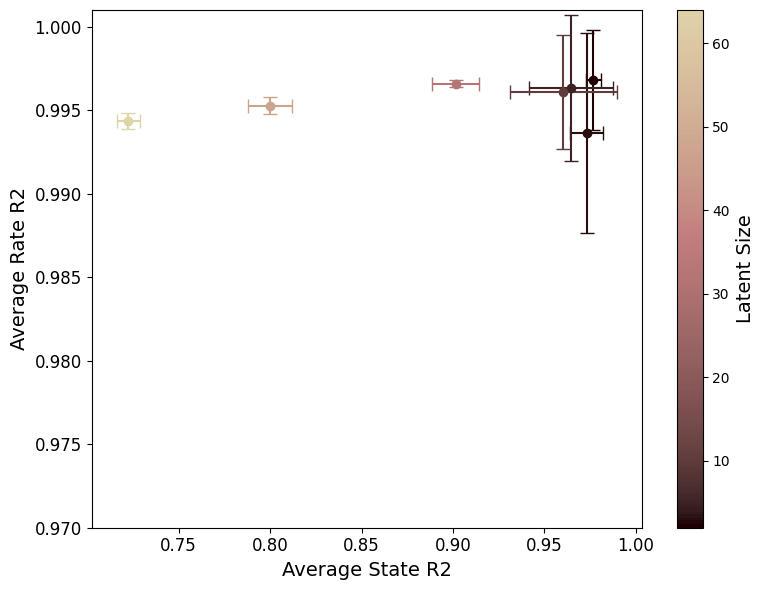

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

def format_axes(ax, title, xlabel, ylabel, fontsize=14):
    """
    Applies consistent formatting to a matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes): The axis to format.
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        fontsize (int): Font size for labels and title.
    """
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)

# Group data by latent size
latent_sizes = metrics_dict["20250407_PC_NODE_grid_final_latent_size"]
unique_latent_sizes = np.unique(latent_sizes)

# Prepare data for error bars
avg_state_r2 = []
std_state_r2 = []
avg_rate_r2 = []
std_rate_r2 = []

for size in unique_latent_sizes:
    indices = [i for i, val in enumerate(latent_sizes) if val == size]
    avg_state_r2.append(np.mean([metrics_dict["state_r2"][i] for i in indices]))
    std_state_r2.append(np.std([metrics_dict["state_r2"][i] for i in indices]))
    avg_rate_r2.append(np.mean([metrics_dict["rate_r2"][i] for i in indices]))
    std_rate_r2.append(np.std([metrics_dict["rate_r2"][i] for i in indices]))

# Normalize latent sizes for color mapping
cmap = cm.pink
norm = mcolors.Normalize(vmin=min(unique_latent_sizes), vmax=max(unique_latent_sizes))
half_cmap = ListedColormap(cmap(np.linspace(0, 0.65, 256)))
colors = half_cmap(norm(unique_latent_sizes))

# Plot with error bars and color coding
fig, ax = plt.subplots(figsize=(8, 6))
for i, size in enumerate(unique_latent_sizes):
    ax.errorbar(
        avg_state_r2[i],
        avg_rate_r2[i],
        xerr=std_state_r2[i],
        yerr=std_rate_r2[i],
        fmt="o",
        color=colors[i],
        label=f"Latent Size {size}",
        capsize=5,
    )
    
# special data point
ax.errorbar(
    0.8,
    0.9952717,
    xerr=0.012,
    yerr=0.0005,
    fmt="o",
    color=((colors[4]+colors[5])/2),
    label=f"Latent Size {size}",
    capsize=5,
)
    
ax.set_ylim([0.97, 1.001])

# Add color bar
sm = cm.ScalarMappable(cmap=half_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Latent Size", fontsize=14)

# Apply formatting
format_axes(ax, "Average State and Rate R2 by Latent Size", "Average State R2", "Average Rate R2")

plt.tight_layout()
plt.show()

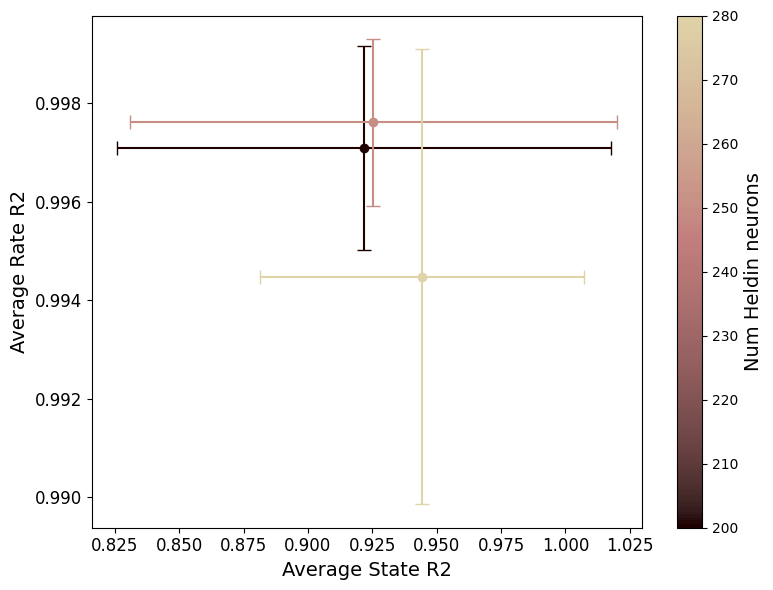

In [119]:
# Group data by latent size
import pandas as pd

latent_sizes = metrics_dict["_n_heldin"]

for i, item in enumerate(latent_sizes):
    if not pd.isna(item):
        latent_sizes[i] = int(item)

unique_latent_sizes = np.unique(latent_sizes)

# Prepare data for error bars
avg_state_r2 = []
std_state_r2 = []
avg_rate_r2 = []
std_rate_r2 = []

for size in unique_latent_sizes:
    indices = [i for i, val in enumerate(latent_sizes) if val == size]
    avg_state_r2.append(np.mean([metrics_dict["state_r2"][i] for i in indices]))
    std_state_r2.append(np.std([metrics_dict["state_r2"][i] for i in indices]))
    avg_rate_r2.append(np.mean([metrics_dict["rate_r2"][i] for i in indices]))
    std_rate_r2.append(np.std([metrics_dict["rate_r2"][i] for i in indices]))

# Normalize latent sizes for color mapping
cmap = cm.pink
norm = mcolors.Normalize(vmin=min(unique_latent_sizes), vmax=max(unique_latent_sizes))
half_cmap = ListedColormap(cmap(np.linspace(0, 0.65, 256)))
colors = half_cmap(norm(unique_latent_sizes))

# Plot with error bars and color coding
fig, ax = plt.subplots(figsize=(8, 6))
for i, size in enumerate(unique_latent_sizes):
    ax.errorbar(
        avg_state_r2[i],
        avg_rate_r2[i],
        xerr=std_state_r2[i],
        yerr=std_rate_r2[i],
        fmt="o",
        color=colors[i],
        label=f"Latent Size {size}",
        capsize=5,
    )
    
# # special data point
# ax.errorbar(
#     0.8,
#     0.9952717,
#     xerr=0.012,
#     yerr=0.0005,
#     fmt="o",
#     color=((colors[4]+colors[5])/2),
#     label=f"Latent Size {size}",
#     capsize=5,
# )
    
# ax.set_ylim([0.97, 1.001])

# Add color bar
sm = cm.ScalarMappable(cmap=half_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Num Heldin neurons", fontsize=14)

# Apply formatting
format_axes(ax, "Average State and Rate R2 by Latent Size", "Average State R2", "Average Rate R2")

plt.tight_layout()
plt.show()

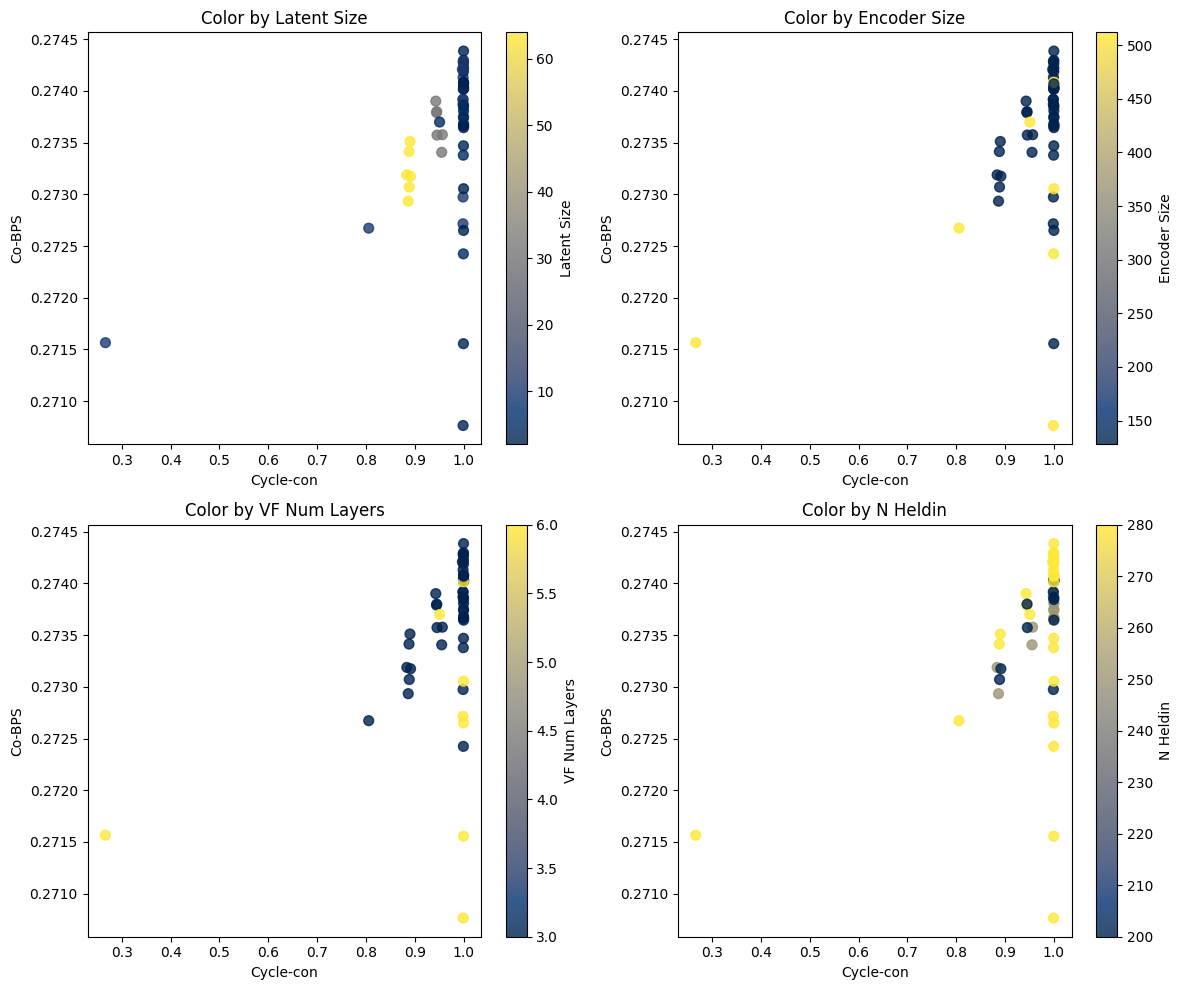

In [22]:
# PLOTTING NOT GROUND TRUTH METRICS

# Create a scatter plot for each relationship
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot 1: Color by latent_size
sc1 = axes[0, 0].scatter(
    metrics_dict["cycle_con"],
    metrics_dict["co-bps"],
    c=[int(val) for val in metrics_dict["20250407_PC_NODE_grid_final_latent_size"]],
    cmap="cividis",
    s=50,
    alpha=0.8,
)
axes[0, 0].set_title("Color by Latent Size")
axes[0, 0].set_ylabel("Co-BPS")
axes[0, 0].set_xlabel("Cycle-con")
fig.colorbar(sc1, ax=axes[0, 0], label="Latent Size")

# Scatter plot 2: Color by encoder_size
sc2 = axes[0, 1].scatter(
    metrics_dict["cycle_con"],
    metrics_dict["co-bps"],
    c=[int(val) for val in metrics_dict["_encoder_size"]],
    cmap="cividis",
    s=50,
    alpha=0.8,
)
axes[0, 1].set_title("Color by Encoder Size")
axes[0, 1].set_ylabel("Co-BPS")
axes[0, 1].set_xlabel("Cycle-con")
fig.colorbar(sc2, ax=axes[0, 1], label="Encoder Size")

# Scatter plot 3: Color by vf_num_layers
sc3 = axes[1, 0].scatter(
    metrics_dict["cycle_con"],
    metrics_dict["co-bps"],
    c=[int(val) for val in metrics_dict["_vf_num_layers"]],
    cmap="cividis",
    s=50,
    alpha=0.8,
)
axes[1, 0].set_title("Color by VF Num Layers")
axes[1, 0].set_ylabel("Co-BPS")
axes[1, 0].set_xlabel("Cycle-con")
fig.colorbar(sc3, ax=axes[1, 0], label="VF Num Layers")

# Scatter plot 4: Color by n_heldin
sc4 = axes[1, 1].scatter(
    metrics_dict["cycle_con"],
    metrics_dict["co-bps"],
    c=[int(val) for val in metrics_dict["_n_heldin"]],
    cmap="cividis",
    s=50,
    alpha=0.8,
)
axes[1, 1].set_title("Color by N Heldin")
axes[1, 1].set_ylabel("Co-BPS")
axes[1, 1].set_xlabel("Cycle-con")
fig.colorbar(sc4, ax=axes[1, 1], label="N Heldin")

plt.tight_layout()
plt.show()

## Compare nonlinear metrics: DSA

First need to find the optimal DSA params (from the TT sim model...)

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 2
Finished optimizing C
Finished optimizing C


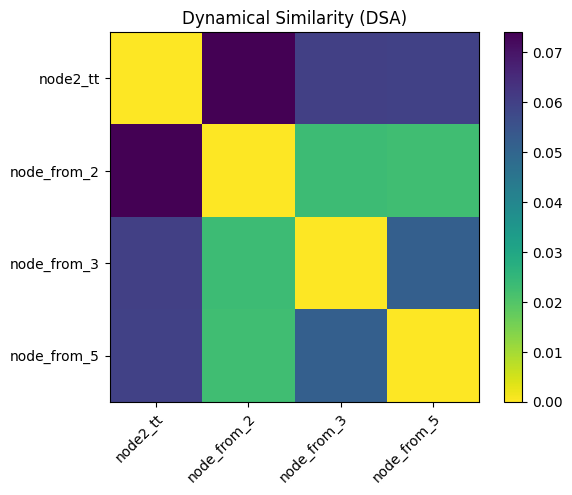

In [8]:
similarities = node_tt_2_node.compare_dynamics_DSA(phase="val",
                                                    n_delays=25,
                                                    rank=50,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 2
Finished optimizing C
Finished optimizing C


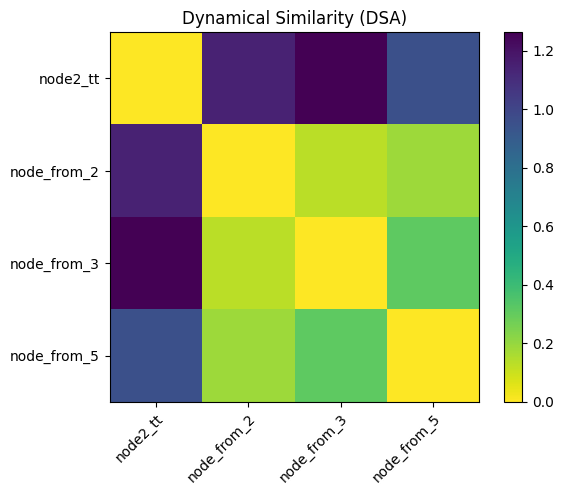

In [9]:
similarities = node_tt_2_node.compare_dynamics_DSA(phase="val",
                                                    n_delays=50,
                                                    rank=100,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

## NODE TT, NODE DD

1. Easiest trials: 0 noise, 39:1, sizes: 2,3,5, inputs provided


DO: sweep through noise levels, sweep through latents, both for and w/o inputs. 0.75 error already has good reconstruction

In [2]:
tt_path = HOME_DIR + "content/trained_models/task-trained/"
tt_sweep = "20250323_PClicks_NODE_grid/"
lat2 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08" 
lat3 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=3_layer_hidden_size=128_latent_l2_wt=1.00E-08" 
lat5 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=5_layer_hidden_size=128_latent_l2_wt=1.00E-08"

l2 = Analysis_TT(run_name = "lat2_node_pc", filepath= tt_path + tt_sweep + lat2 + "/")  #13
l3 = Analysis_TT(run_name = "lat3_node_pc", filepath= tt_path + tt_sweep + lat3 + "/")  #52
l5 = Analysis_TT(run_name = "lat5_node_pc", filepath= tt_path + tt_sweep + lat5 + "/")  #66
# l2.plot_trial_io(num_trials= 5)
# l3.plot_trial_io(num_trials= 5)
# l5.plot_trial_io(num_trials= 5)

Analysis_DD has access to the TT datamodule and uses it to get the metrics
* metrics taken over val phase

* for metrics, group different models (lat, noise) coming from the same sim TT model (one ref)

* for DSA, group same models (latents), can be different noise, architecture, from same/diff sim TT model (one ref)

In [3]:
dd_sweep = "tt_PClicks/20250325_NODE_on_PC_NODE_false/"

# from lat2 sim
dd_lat2 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=13']#,
# 'prefix=20250323_PClicks_NODE_grid_latent_size=3_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=13']

# from lat3 sim
dd_lat3 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=52']

# form lat5 sim
dd_lat5 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=66']

comp_node_lat2 = Comparison(comparison_tag = "node_pc")
comp_node_lat2.load_analysis(l2, group = "tt_lat2_node_pc", reference_analysis=True)
lat_sizes = []

# for subfolder in dd_lat2:
lat = [2,3,5]
for index, subfolder in enumerate([dd_lat2, dd_lat3, dd_lat5]):
    subfolder = tt_path + dd_sweep + subfolder[0] + "/"
    #lat_size = int(subfolder.split("latent_size=")[1].split("_")[0])
    ana_node_lat2 = Analysis_DD.create(run_name = f"node_from_{lat[index]}", filepath = subfolder, model_type = "SAE")
    # print(f"NODE_{lat_size}")
    # lat_sizes.append(lat_size)
    comp_node_lat2.load_analysis(ana_node_lat2, group = "tt_lat2_node_pc")

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [4]:
# all DD latent size 2, from diff TT lat sizes
metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_node_lat2 = comp_node_lat2.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)


Working on 1 of 4: lat2_node_pc

Working on 2 of 4: node_from_2
State R2: 0.9961092472076416
Rate R2: 0.9979206323623657
CO-BPS: 0.11508102715015411
Cycle Consistency R2: 0.9998958706855774

Working on 3 of 4: node_from_3
State R2: 0.9995246529579163
Rate R2: 0.9986978769302368
CO-BPS: 0.138174906373024
Cycle Consistency R2: 0.9998559355735779

Working on 4 of 4: node_from_5
State R2: 0.9852018356323242
Rate R2: 0.9951635599136353
CO-BPS: 0.11627038568258286
Cycle Consistency R2: 0.9998025894165039


In [4]:
# DD diff latent sizes, fromk TT latent size 2
metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_node_lat2 = comp_node_lat2.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)


Working on 1 of 3: lat2_node_pc

Working on 2 of 3: node_2
State R2: 0.996151328086853
Rate R2: 0.9979293942451477
CO-BPS: 0.11508277803659439
Cycle Consistency R2: 0.9999023079872131

Working on 3 of 3: node_3
State R2: 0.9929505586624146
Rate R2: 0.9988576769828796
CO-BPS: 0.11542218178510666
Cycle Consistency R2: 0.9964902997016907


In [14]:
                # X,
                # Y=None,
                # n_delays=1,
                # delay_interval=1,
                # rank=None,
                # rank_thresh=None,
                # rank_explained_variance = None,
                # lamb = 0.0,
                # send_to_cpu = True,
                # iters = 1500,
                # score_method: Literal["angular", "euclidean","wasserstein"] = "angular",
                # lr = 5e-3,
                # group: Literal["GL(n)", "O(n)", "SO(n)"] = "O(n)",
                # zero_pad = False,
                # device = 'cpu',
                # verbose = False,
                # reduced_rank_reg = False,
                # kernel=None,
                # num_centers=0.1,
                # svd_solver='arnoldi',
                # wasserstein_compare: Literal['sv','eig',None] = None

        # Parameters
        # __________

        # X : np.array or torch.tensor or list of np.arrays or torch.tensors
        #     first data matrix/matrices
        
        # Y : None or np.array or torch.tensor or list of np.arrays or torch.tensors
        #     second data matrix/matrices. 
        #     * If Y is None, X is compared to itself pairwise 
        #     (must be a list)
        #     * If Y is a single matrix, all matrices in X are compared to Y
        #     * If Y is a list, all matrices in X are compared to all matrices in Y
        
        # DMD parameters: 

        # n_delays : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     number of delays to use in constructing the Hankel matrix
        
        # delay_interval : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     interval between samples taken in constructing Hankel matrix

        # rank : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     rank of DMD matrix fit in reduced-rank regression
        
        # rank_thresh : float or list or tuple/list: (float,float), (list,list),(list,float),(float,list)
        #     Parameter that controls the rank of V in fitting HAVOK DMD by dictating a threshold
        #     of singular values to use. Explicitly, the rank of V will be the number of singular
        #     values greater than rank_thresh. Defaults to None.
        
        # rank_explained_variance : float or list or tuple: (float,float), (list,list),(list,float),(float,list)
        #     Parameter that controls the rank of V in fitting HAVOK DMD by indicating the percentage of
        #     cumulative explained variance that should be explained by the columns of V. Defaults to None.
        
        # lamb : float
        #     L-1 regularization parameter in DMD fit
        
        # send_to_cpu: bool
        #     If True, will send all tensors in the object back to the cpu after everything is computed.
        #     This is implemented to prevent gpu memory overload when computing multiple DMDs.

        # NOTE: for all of these above, they can be single values or lists or tuples,
        #     depending on the corresponding dimensions of the data
        #     If at least one of X and Y are lists, then if they are a single value
        #         it will default to the rank of all DMD matrices. 
        #     If they are (int,int), then they will correspond to an individual dmd matrix
        #         OR to X and Y respectively across all matrices
        #     If it is (list,list), then each element will correspond to an individual
        #         dmd matrix indexed at the same position

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished

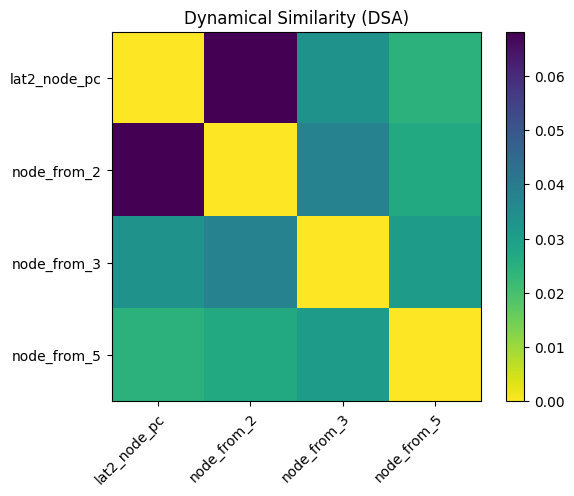

In [6]:
similarities = comp_node_lat2.compare_dynamics_DSA(phase="val",
                                                    n_delays=20,
                                                    rank=50,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

In [7]:
metrics = ["state_r2", "rate_r2", "co-bps", "cycle_con"]
mean_metrics = {k:[] for k in metrics}
for lat in np.unique(lat_sizes):
    for met in metrics:
        met_list = np.array(metrics_NODE[met])
        lat_met = met_list[lat_sizes == lat]
        mean_metrics[met].append([lat, np.mean(lat_met)])

for met in metrics:
    mean_metrics[met] = np.array(mean_metrics[met])